# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [33]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from config import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [34]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name
    
    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 591


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [35]:
# Set the API base URL
url = "http://api.openweathermap.org/data/2.5/weather"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):
        
    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f"{url}?q={city}&appid={weather_api_key}"
    
    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Parse the JSON and retrieve data
        response = requests.get(city_url)
        city_weather = response.json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]['lon']
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city, 
                          "Lat": city_lat, 
                          "Lng": city_lng, 
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except Exception as e:
        print("City not found. Skipping...")
        pass

    #Pause to void rate limiting 
    time.sleep(1)          
# Indicate that Data Loading is complete 
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | smithers
Processing Record 2 of Set 1 | waitangi
Processing Record 3 of Set 1 | nelson bay
Processing Record 4 of Set 1 | new plymouth
Processing Record 5 of Set 1 | namibe
Processing Record 6 of Set 1 | hermanus
Processing Record 7 of Set 1 | antigonish
Processing Record 8 of Set 1 | gizo
Processing Record 9 of Set 1 | thompson
Processing Record 10 of Set 1 | coyhaique
Processing Record 11 of Set 1 | talnakh
Processing Record 12 of Set 1 | alofi
Processing Record 13 of Set 1 | taiohae
City not found. Skipping...
Processing Record 14 of Set 1 | kyshtovka
Processing Record 15 of Set 1 | carutapera
Processing Record 16 of Set 1 | riachao
Processing Record 17 of Set 1 | arthur's town
City not found. Skipping...
Processing Record 18 of Set 1 | wynyard
Processing Record 19 of Set 1 | puerto san carlos
City not found. Skipping...
Processing Record 20 of Set 1 | susuman
Processing Record 21 of Set 1 | h

In [57]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          564
Lat           564
Lng           564
Max Temp      564
Humidity      564
Cloudiness    564
Wind Speed    564
Country       564
Date          564
dtype: int64

In [58]:
# Display sample data
city_data_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,smithers,54.7804,-127.1743,298.33,33,62,7.20,CA,1787095744
1,waitangi,-43.9535,-176.5597,281.94,77,86,3.58,NZ,1787095748
2,nelson bay,-32.7167,152.1500,289.88,89,32,0.89,AU,1787095927
3,new plymouth,-39.0667,174.0833,282.77,100,41,3.93,NZ,1787095928
4,namibe,-15.1961,12.1522,291.92,86,57,2.24,AO,1787095609
5,hermanus,-34.4187,19.2345,284.65,88,100,3.80,ZA,1787095568
6,antigonish,45.6169,-61.9986,293.25,98,100,1.79,CA,1787095931
7,gizo,-8.1030,156.8419,299.20,75,84,9.49,SB,1787095932
8,thompson,55.7435,-97.8558,288.24,63,96,3.09,CA,1787095533
9,coyhaique,-45.5752,-72.0662,276.50,99,100,3.36,CL,1787095934


In [59]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [60]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,smithers,54.7804,-127.1743,298.33,33,62,7.20,CA,1787095744
1,waitangi,-43.9535,-176.5597,281.94,77,86,3.58,NZ,1787095748
2,nelson bay,-32.7167,152.1500,289.88,89,32,0.89,AU,1787095927
3,new plymouth,-39.0667,174.0833,282.77,100,41,3.93,NZ,1787095928
4,namibe,-15.1961,12.1522,291.92,86,57,2.24,AO,1787095609


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

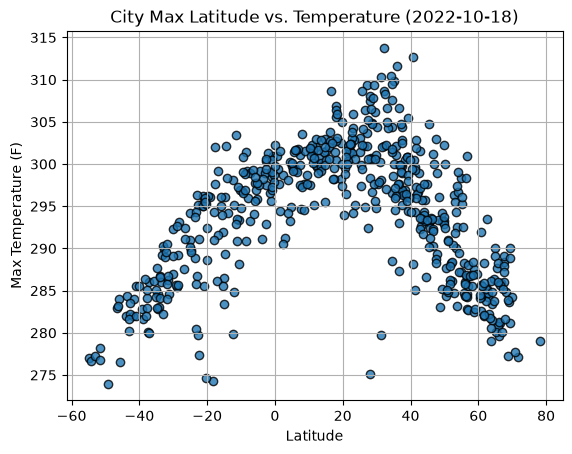

In [61]:
# Build scatter plot for latitude vs. temperature
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (F)")
plt.title("City Max Latitude vs. Temperature (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

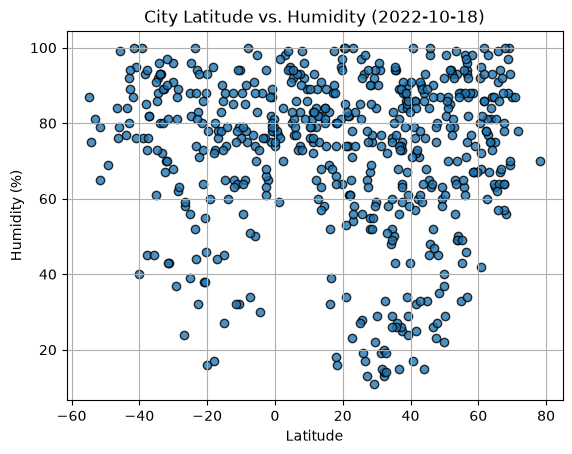

In [62]:
# Build the scatter plots for latitude vs. humidity
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.title("City Latitude vs. Humidity (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

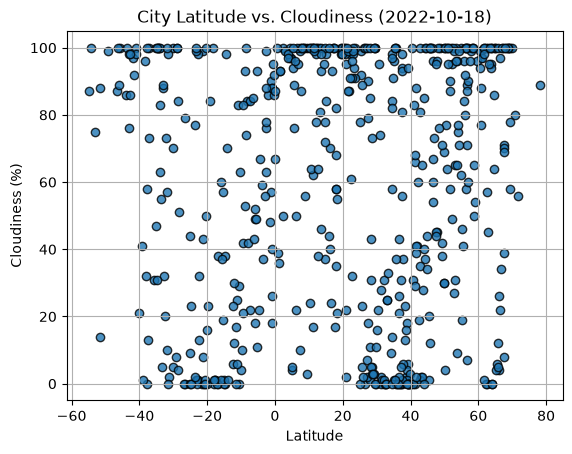

In [63]:
# Build the scatter plots for latitude vs. cloudiness
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.title("City Latitude vs. Cloudiness (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

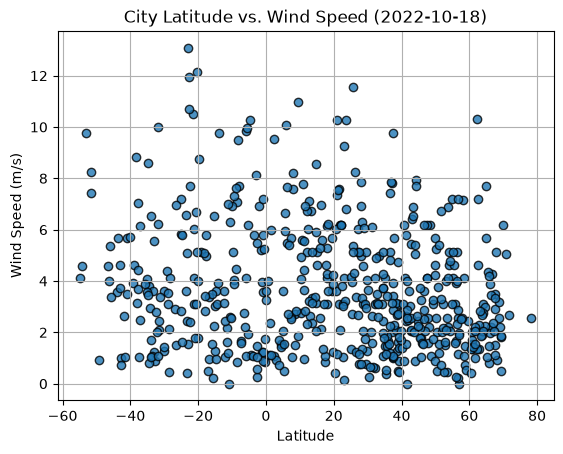

In [64]:
# Build the scatter plots for latitude vs. wind speed
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolors="black", alpha=0.80)

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.title("City Latitude vs. Wind Speed (2022-10-18)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [65]:
# Define a function to create Linear Regression plots
city_data_df = pd.DataFrame(city_data)

In [66]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >= 0]

# Display sample data
northern_hemi_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,smithers,54.7804,-127.1743,298.33,33,62,7.20,CA,1787095744
6,antigonish,45.6169,-61.9986,293.25,98,100,1.79,CA,1787095931
8,thompson,55.7435,-97.8558,288.24,63,96,3.09,CA,1787095533
10,talnakh,69.4865,88.3972,290.01,69,58,1.80,RU,1787095747
12,kyshtovka,56.5550,76.6271,282.80,94,71,2.55,RU,1787095791
16,susuman,62.7833,148.1667,284.27,77,100,1.34,RU,1787095945
17,holualoa,19.6228,-155.9522,298.19,95,98,3.60,US,1787095782
18,stanley,54.8680,-1.6985,287.17,88,100,3.09,GB,1787095591
20,iskateley,67.6803,53.1512,288.41,78,71,1.51,RU,1787095749
21,colares,38.7992,-9.4469,296.11,86,2,1.26,PT,1787095756


In [67]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df["Lat"] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
1,waitangi,-43.9535,-176.5597,281.94,77,86,3.58,NZ,1787095748
2,nelson bay,-32.7167,152.1500,289.88,89,32,0.89,AU,1787095927
3,new plymouth,-39.0667,174.0833,282.77,100,41,3.93,NZ,1787095928
4,namibe,-15.1961,12.1522,291.92,86,57,2.24,AO,1787095609
5,hermanus,-34.4187,19.2345,284.65,88,100,3.80,ZA,1787095568


###  Temperature vs. Latitude Linear Regression Plot

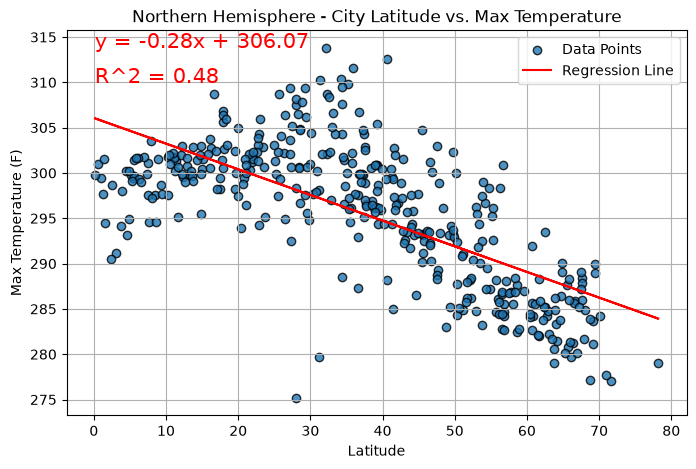

In [74]:
# Extract the variables
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Max Temp"]   # Convert from Kelvin to Fahrenheit if needed

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)

# Create regression line values
regress_values = x_values * slope + intercept
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Build scatter plot
plt.figure(figsize=(8, 5))  
plt.scatter(x_values, y_values, edgecolors="black", alpha=0.80, label="Data Points")

# Plot regression line
plt.plot(x_values, regress_values, "r-", label="Regression Line")

# Incorporate the other graph properties
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (F)")
plt.title("Northern Hemisphere - City Latitude vs. Max Temperature")
plt.grid(True)

# Add line equation and r-squared value to the plot
plt.annotate(line_eq, (min(x_values), max(y_values)), fontsize=15, color="red")
plt.annotate(f"R^2 = {r_value**2:.2f}", (min(x_values), max(y_values) - (max(y_values) - min(y_values)) * 0.1), fontsize=15, color="red")

# Add legend
plt.legend()

# Save the figure
plt.savefig("Fig5.png")

# Show plot
plt.show()

The r^2-value is: 0.6406627716652997


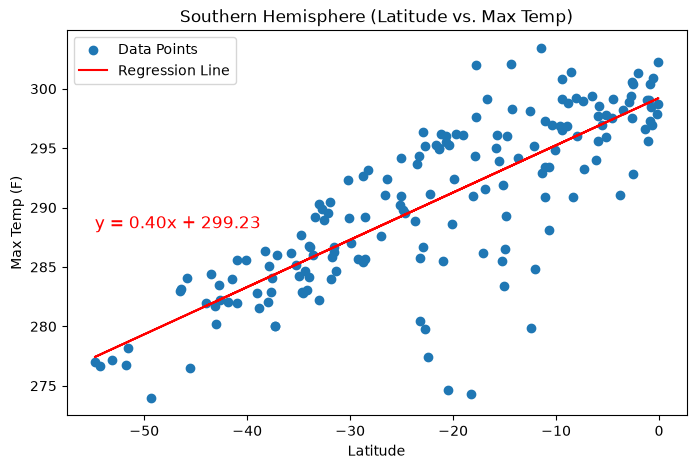

In [75]:
# Linear regression on Southern Hemisphere
x_values = southern_hemi_df["Lat"]
y_values = southern_hemi_df["Max Temp"]
(slope, intercept, r_value, p_value, std_err) = linregress(x_values, y_values)

#calculate predicted values 
regress_values = slope * x_values + intercept

#Step 3: Calculate R^2 Value 
r_squared = r_value**2

#Print R^2 value 
print(f"The r^2-value is: {r_squared}")

#Step 4: Plot the data and regression line 
plt.figure(figsize=(8,5))
plt.scatter(x_values, y_values, label="Data Points")
plt.plot(x_values,regress_values, color="red", label= "Regression Line")
plt.xlabel("Latitude")
plt.ylabel("Max Temp (F)")
plt.title("Southern Hemisphere (Latitude vs. Max Temp)")
plt.legend()

#Add slope equation to the plot 
equation_text = f'y = {slope:.2f}x + {intercept:.2f}'
plt.text(min(x_values), max(y_values)*0.95, equation_text, fontsize=12, color="red")

plt.savefig("Fig6.png")
plt.show()

### Humidity vs. Latitude Linear Regression Plot

The r^2 value is: {r_value**2}


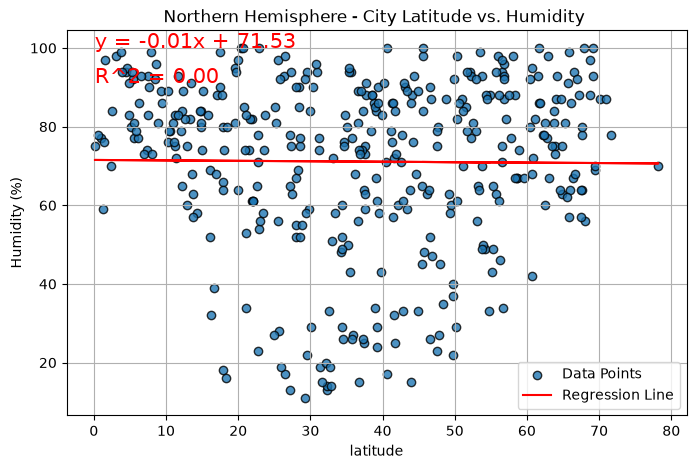

In [80]:
# Northern Hemisphere
city_data_df = pd.DataFrame(city_data)

#Create a DataFrame with the Northern Hemisphere data (Latitude >=0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >=0]

#Extract the variables 
x_values = northern_hemi_df["Lat"]
y_values = northern_hemi_df["Humidity"]

#Perform linear regression 
slope, intercept, r_value, p_value, std_err, = linregress(x_values, y_values)

#Create regression line values 
regress_values = x_values * slope + intercept
line_eq = f'y = {slope:.2f}x + {intercept:.2f}'

#Output the R-squared value
print("The r^2 value is: {r_value**2}")

#Build the scatter plot 
plt.figure(figsize=(8,5))
plt.scatter(x_values, y_values, edgecolors="black", alpha=0.80, label="Data Points")

#Plot the regression line
plt.plot(x_values,regress_values, "r-", label="Regression Line")

#Incorporate the other graph properties 
plt.xlabel("latitude")
plt.ylabel("Humidity (%)")
plt.title("Northern Hemisphere - City Latitude vs. Humidity ")
plt.grid(True)

#Add line equation and r-squared value to the plot 
plt.annotate(line_eq, (min(x_values), max(y_values)), fontsize=15, color="red")
plt.annotate(f"R^2 = {r_value**2:.2f}", (min(x_values), max(y_values) - (max(y_values) - min(y_values)) * 0.1), fontsize=15, color="red")

#Add legend 
plt.legend()

#Save the figure
plt.savefig("Lat_vs_Humidity.png")

#Show plot
plt.show()

The r-value is: 0.0002808747046324607


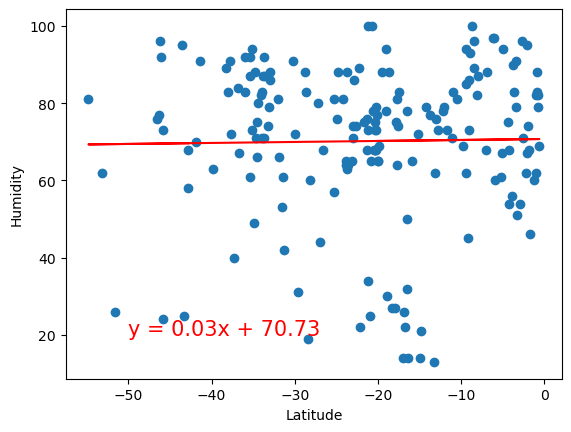

In [ ]:
# Southern Hemisphere
# YOUR CODE HERE

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Cloudiness vs. Latitude Linear Regression Plot

The r-value is: 0.024026517125811015


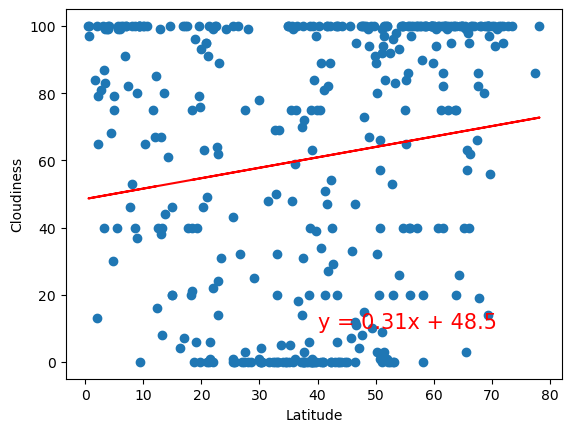

In [ ]:
# Northern Hemisphere
# YOUR CODE HERE

The r-value is: 0.02056735429994368


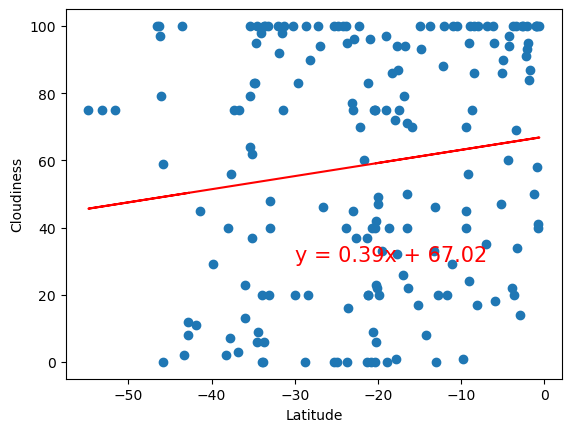

In [ ]:
# Southern Hemisphere
# YOUR CODE HERE

**Discussion about the linear relationship:** YOUR RESPONSE HERE

### Wind Speed vs. Latitude Linear Regression Plot

The r-value is: 0.030396762354449467


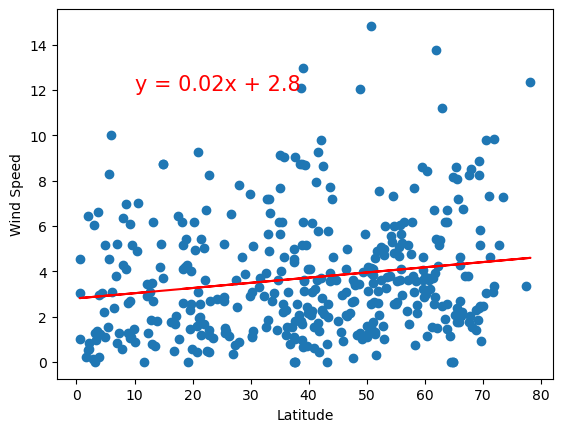

In [ ]:
# Northern Hemisphere
# YOUR CODE HERE

The r-value is: 0.062239040700515696


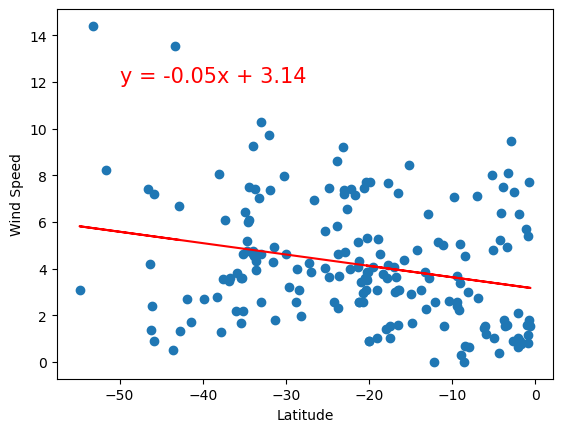

In [ ]:
# Southern Hemisphere
# YOUR CODE HERE

**Discussion about the linear relationship:** YOUR RESPONSE HERE